# Replication Code

This notebook reproduces the augmented synthetic control analyses used to generate the study figures.

The same analytical workflow was applied across all state-specific and outcome-specific analyses. To reproduce a different analysis, the following elements should be updated as appropriate:

- treated state (all references)
- intervention year (all references)
- outcome variable (overall, male, or female)
- figure labels and output file names (all references)

All other data preparation steps, donor pool restrictions, model specifications, placebo tests, and robustness checks were kept consistent across analyses.

This version reproduces the analysis for Colorado (intervention year: 2020) and female firearm homicide rates.

In [13]:
# Install the PySynCon package, which is used to implement the augmented
# synthetic control analyses.

!pip install pysyncon

In [14]:
# Import packages required for data management, visualization, augmented
# synthetic control analyses, and robustness checks.

import pandas as pd
import matplotlib.pyplot as plt

from pysyncon import Dataprep, AugSynth
from pysyncon.utils import PlaceboTest

import numpy as np

from matplotlib.ticker import MaxNLocator

In [15]:
# Load mortality data and construct the analytic sample.
# The CSV file is not included in this repository because it cannot be publicly redistributed.
# States without ERPO laws constitute the donor pool.
# States with suppressed outcome counts are excluded because reliable annual
# outcome rates cannot be calculated for those observations.

deaths = pd.read_csv("Death_and_Population_Data1999.csv")
erpo_states = [
    "California","Colorado","Connecticut","Delaware",
    "District of Columbia (DC)","Florida","Hawaii","Illinois","Indiana",
    "Maryland","Massachusetts","Nevada",
    "New Jersey","New Mexico","New York","Oregon","Rhode Island",
    "Vermont","Virginia","Washington"
]

non_erpo_states = [
    "Alabama","Alaska","Arizona","Arkansas","Georgia","Idaho","Iowa","Kansas",
    "Kentucky","Louisiana","Maine","Michigan","Minnesota","Mississippi","Missouri","Montana","Nebraska",
    "New Hampshire","North Carolina","North Dakota","Ohio","Oklahoma",
    "Pennsylvania","South Carolina","South Dakota","Tennessee","Texas","Utah",
    "West Virginia","Wisconsin","Wyoming"
]

df = pd.concat([
    deaths[deaths["State"].isin(non_erpo_states)],
    deaths[deaths["State"] == "Colorado"]
], ignore_index=True)

df_sub = df[df["Year"] >= 1999].copy()

df_sub["Deaths_str"] = df_sub["Female Firearm Homicides"].astype(str).str.strip().str.lower()

suppressed_states = df_sub.loc[
    df_sub["Deaths_str"].str.contains("suppressed", na=False),
    "State"
].unique().tolist()

df_clean = df_sub[~df_sub["State"].isin(suppressed_states)].copy()

print("State count:", df_clean["State"].nunique())



State count: 32


In [16]:
# Convert analysis variables to numeric format and calculate annual outcome
# rates per 100,000 population.
# The treated state and eligible donor states are then defined for the synthetic
# control analysis.

df_clean["Female Firearm Homicides"] = pd.to_numeric(df_clean["Female Firearm Homicides"], errors="coerce")
df_clean["Population"] = pd.to_numeric(df_clean["Population"], errors="coerce")
df_clean["Year"] = pd.to_numeric(df_clean["Year"], errors="coerce")
df_clean = df_clean.dropna(subset=["Female Firearm Homicides", "Population", "Year"])
df_clean["HomicideRate"] = df_clean["Female Firearm Homicides"] / df_clean["Population"] * 100000

treated_unit = "Colorado"
DONORS = df_clean[
    (df_clean["State"].isin(non_erpo_states)) &
    (df_clean["State"] != treated_unit)
]["State"].unique().tolist()
print("Number of control states:", len(DONORS))

Number of control states: 31


In [17]:
# Construct the augmented synthetic control model and estimate the synthetic
# comparison unit using pre-intervention outcome and predictors information.
# Donor-state weights are reported.

df_clean["HomicideRate"] = df_clean["Female Firearm Homicides"] / df_clean["Population"] * 100000
dataprep = Dataprep(
    foo=df_clean,
    predictors=["Population","Firearm Purchase"],
    predictors_op="mean",
    time_predictors_prior=range(1999, 2020),
    dependent="HomicideRate",
    unit_variable="State",
    time_variable="Year",
    treatment_identifier=treated_unit,
    controls_identifier=DONORS,
    time_optimize_ssr=range(1999, 2020),
)

augs = AugSynth()
augs.fit(dataprep=dataprep)
print("Weights ")
w = augs.weights(threshold=0.001)
open("weights.txt","w").close()
for k, v in sorted(w.items(), key=lambda x: x[1], reverse=True):
    print(f"{k}: {v}"); open("weights.txt","a").write(f"{k}: {v}\n")

Weights 
Pennsylvania: 0.464
Wisconsin: 0.208
South Carolina: 0.197
North Dakota: 0.177
North Carolina: 0.163
South Dakota: 0.142
Tennessee: 0.102
Kansas: 0.093
Utah: 0.082
Iowa: 0.066
Wyoming: 0.064
West Virginia: 0.059
Arizona: 0.054
New Hampshire: 0.025
Alaska: 0.02
Kentucky: 0.019
Louisiana: 0.013


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

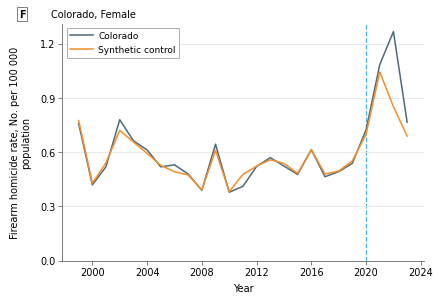

In [18]:
# Generate and export the augmented synthetic control figure.
# The plot compares the observed homicide rate for the treated state
# with the estimated synthetic control over the full study period.
# The vertical dashed line indicates the intervention year.

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from google.colab import files

plt.show = lambda *args, **kwargs: None

# SYNTHETIC CONTROL PLOT

augs.path_plot(
    time_period=range(1999, 2024),
    treatment_time=2020
)

ax = plt.gca()
fig = plt.gcf()

fig.set_size_inches(4.4, 3.0)

# Remove default vertical line so it can be redrawn
# using the preferred figure style.

for line in list(ax.lines):
    xdata = line.get_xdata()
    if len(xdata) == 2 and xdata[0] == xdata[1]:
        line.remove()

# Apply line colors, labels, and formatting for the treated unit and its
# synthetic control.

for i, line in enumerate(ax.lines):
    if i == 0:
        line.set_color("#4E6A79")
        line.set_linewidth(1.1)
        line.set_linestyle("-")
        line.set_label("Colorado")
    else:
        line.set_color("#F28E2B")
        line.set_linewidth(1.1)
        line.set_linestyle("-")
        line.set_label("Synthetic control")

# Intervention line/year
ax.axvline(
    x=2020,
    ymin=0,
    ymax=1,
    color="#43B5E8",
    linestyle="--",
    linewidth=0.9,
    zorder=0
)

ax.set_xlabel("Year", fontsize=7, labelpad=4)

ax.set_ylabel(
    "Firearm homicide rate, No. per 100 000\npopulation",
    fontsize=7,
    labelpad=6
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=7,
    length=3,
    width=0.6,
    color="#666666",
    pad=2
)

ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=7))

ax.set_axisbelow(True)

ax.grid(
    axis="y",
    which="major",
    color="#E6E6E6",
    linewidth=0.6,
    linestyle="-"
)

ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)
    ax.spines[spine].set_color("#666666")

ax.set_ylim(bottom=0)

legend = ax.legend(
    loc="best",
    fontsize=6.5,
    frameon=True,
    fancybox=False,
    edgecolor="#999999",
    facecolor="white",
    framealpha=0.95,
    borderpad=0.4,
    handlelength=2.5,
    handletextpad=0.6
)

legend.get_frame().set_linewidth(0.6)

# Panel letter
ax.text(
    -0.12,
    1.06,
    "F",
    transform=ax.transAxes,
    fontsize=7,
    fontweight="bold",
    va="top",
    ha="left",
    bbox=dict(
        boxstyle="square,pad=0.2",
        facecolor="white",
        edgecolor="#666666",
        linewidth=0.6
    )
)

# Panel title
ax.text(
    -0.03,
    1.06,
    "Colorado, Female",
    transform=ax.transAxes,
    fontsize=7,
    va="top",
    ha="left"
)

plt.tight_layout(pad=0.6)

plt.savefig("Figure1.pdf", format="pdf", bbox_inches="tight")

files.download("Figure1.pdf")

(1/31) Completed placebo test for Alaska.
(2/31) Completed placebo test for Alabama.
(3/31) Completed placebo test for Arizona.
(4/31) Completed placebo test for Arkansas.
(5/31) Completed placebo test for Georgia.
(6/31) Completed placebo test for Idaho.
(7/31) Completed placebo test for Iowa.
(8/31) Completed placebo test for Kansas.
(9/31) Completed placebo test for Louisiana.
(10/31) Completed placebo test for Kentucky.
(11/31) Completed placebo test for Maine.
(12/31) Completed placebo test for Michigan.
(13/31) Completed placebo test for Mississippi.
(14/31) Completed placebo test for Minnesota.
(15/31) Completed placebo test for Missouri.
(16/31) Completed placebo test for Montana.
(17/31) Completed placebo test for Nebraska.
(18/31) Completed placebo test for New Hampshire.
(19/31) Completed placebo test for North Carolina.
(20/31) Completed placebo test for North Dakota.
(21/31) Completed placebo test for Oklahoma.
(22/31) Completed placebo test for Ohio.
(23/31) Completed pla

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

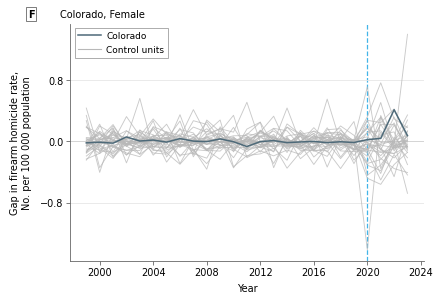

In [19]:
# Conduct placebo tests and export the gap plot.
# The figure compares the treated-state gap with placebo gaps
# estimated for donor states. The vertical dashed line indicates
# the intervention year, and the horizontal line marks a zero gap.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from google.colab import files

plt.show = lambda *args, **kwargs: None

placebo_test = PlaceboTest()
placebo_test.fit(dataprep=dataprep, scm=augs)

placebo_test.gaps_plot(
    time_period=range(1999, 2024),
    treatment_time=2020
)

ax = plt.gca()
fig = plt.gcf()
fig.set_size_inches(4.4, 3.0)

treated_gap = placebo_test.treated_gap.loc[range(1999, 2024)].values

# remove default vertical line
for line in list(ax.lines):
    xdata = line.get_xdata()
    if len(xdata) == 2 and xdata[0] == xdata[1]:
        line.remove()

# style lines
for line in ax.lines:
    ydata = np.asarray(line.get_ydata())

    if len(ydata) == len(treated_gap) and np.allclose(ydata, treated_gap, equal_nan=True):
        line.set_color("#4E6A79")
        line.set_linewidth(1.1)
        line.set_alpha(1.0)
        line.set_zorder(3)
        line.set_label("Colorado")
    else:
        line.set_color("#B8B8B8")
        line.set_linewidth(0.65)
        line.set_alpha(0.75)
        line.set_zorder(1)
        line.set_label("_nolegend_")

ax.plot([], [], color="#B8B8B8", linewidth=0.8, label="Control units")

ax.axhline(0, color="#666666", linewidth=0.6, linestyle="-", zorder=0)

ax.axvline(
    x=2020,
    ymin=0,
    ymax=1,
    color="#43B5E8",
    linestyle="--",
    linewidth=0.9,
    zorder=0
)

ax.set_title("")
ax.set_xlabel("Year", fontsize=7, labelpad=4)
ax.set_ylabel(
    "Gap in firearm homicide rate,\nNo. per 100 000 population",
    fontsize=7,
    labelpad=6
)

ax.tick_params(axis="both", which="major", labelsize=7, length=3, width=0.6, color="#666666", pad=2)
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=7))

ax.set_axisbelow(True)
ax.grid(axis="y", which="major", color="#E6E6E6", linewidth=0.6, linestyle="-")
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)
    ax.spines[spine].set_color("#666666")

legend = ax.legend(
    loc="best",
    fontsize=6.5,
    frameon=True,
    fancybox=False,
    edgecolor="#999999",
    facecolor="white",
    framealpha=0.95,
    borderpad=0.4,
    handlelength=2.5,
    handletextpad=0.6
)
legend.get_frame().set_linewidth(0.6)

ax.text(
    -0.12, 1.06, "F",
    transform=ax.transAxes,
    fontsize=7,
    fontweight="bold",
    va="top",
    ha="left",
    bbox=dict(boxstyle="square,pad=0.2", facecolor="white", edgecolor="#666666", linewidth=0.6)
)

ax.text(
    -0.03, 1.06,
    "Colorado, Female",
    transform=ax.transAxes,
    fontsize=7,
    va="top",
    ha="left"
)

plt.tight_layout(pad=0.6)

plt.savefig("Figure2.pdf", format="pdf", bbox_inches="tight")

files.download("Figure2.pdf")

In [20]:
# Calculate the placebo-test p-value to assess whether the
# estimated treatment effect is larger than effects observed
# among donor-state placebo interventions.

pval = placebo_test.pvalue(treatment_time=2020)
print(f"p-value: {pval}")

p-value: 0.0


Top donors: ['Pennsylvania', 'Wisconsin', 'South Carolina']
Baseline pre-RMSPE: 0.0248
Exclude Pennsylvania: 0.0419
Exclude Wisconsin: 0.0317
Exclude South Carolina: 0.0514


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

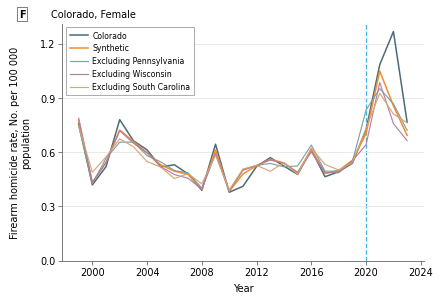

In [21]:
# Conduct a leave-one-out robustness analysis.
# The baseline augmented synthetic control model is re-estimated
# after excluding each of the highest-weight donor states one at a time.
# This assesses whether the results are driven by any single donor state.
# The resulting trajectories are plotted against the treated unit and
# the baseline synthetic control.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from pysyncon import Dataprep, AugSynth

plt.show = lambda *args, **kwargs: None

# SETTINGS

PRE_YEARS = range(1999, 2020)
ALL_YEARS = range(1999, 2024)
T0 = 2020

predictors = ["Population", "Firearm Purchase"]

# FIT FUNCTION

def fit_augsynth_with_donors(donors_list):

    dp = Dataprep(
        foo=df_clean,
        predictors=predictors,
        predictors_op="mean",
        time_predictors_prior=PRE_YEARS,
        dependent="HomicideRate",
        unit_variable="State",
        time_variable="Year",
        treatment_identifier=treated_unit,
        controls_identifier=donors_list,
        time_optimize_ssr=PRE_YEARS,
    )

    model = AugSynth()
    model.fit(dataprep=dp)

    Y = (
        df_clean
        .pivot(index="Year", columns="State", values="HomicideRate")
        .sort_index()
    )

    w = model.weights()

    y_synth = (Y[w.index] @ w).loc[ALL_YEARS]
    y_treat = Y[treated_unit].loc[ALL_YEARS]

    pre_rmspe = float(
        np.sqrt(
            np.mean(
                (y_treat.loc[PRE_YEARS] - y_synth.loc[PRE_YEARS]) ** 2
            )
        )
    )

    return model, y_treat, y_synth, pre_rmspe


# BASE MODEL

base_model, y_treat, y_synth_base, pre_rmspe_base = (
    fit_augsynth_with_donors(DONORS)
)

w_base = base_model.weights()

top_donors = [
    k for k, v in sorted(
        w_base.items(),
        key=lambda x: x[1],
        reverse=True
    )[:3]
]

print("Top donors:", top_donors)
print("Baseline pre-RMSPE:", round(pre_rmspe_base, 4))

# LEAVE-ONE-OUT

loo_results = {}

for d in top_donors:

    donors_loo = [x for x in DONORS if x != d]

    m, _, y_synth_loo, pre_rmspe_loo = (
        fit_augsynth_with_donors(donors_loo)
    )

    loo_results[d] = (y_synth_loo, pre_rmspe_loo)

    print(
        f"Exclude {d}:",
        round(pre_rmspe_loo, 4)
    )

# STYLE FIGURE

fig, ax = plt.subplots(figsize=(4.4, 3.0))

# Treated line
ax.plot(
    list(ALL_YEARS),
    y_treat.values,
    color="#4E6A79",
    linewidth=1.1,
    linestyle="-",
    label=f"{treated_unit}"
)

# Baseline synthetic line
ax.plot(
    list(ALL_YEARS),
    y_synth_base.values,
    color="#F28E2B",
    linewidth=1.1,
    linestyle="-",
    label="Synthetic"
)

# Leave-one-out colors
loo_colors = [
    "#7A9E9F",
    "#B07AA1",
    "#D4A373",
    "#8AB17D",
    "#A6A6A6",
    "#9C89B8"
]

# Leave-one-out lines
for i, (d, (ys, rmspe)) in enumerate(loo_results.items()):

    ax.plot(
        list(ALL_YEARS),
        ys.values,
        color=loo_colors[i % len(loo_colors)],
        linewidth=0.85,
        linestyle="-",
        alpha=0.95,
        label=f"Excluding {d}"
    )

# Intervention line
ax.axvline(
    x=T0,
    ymin=0,
    ymax=1,
    color="#43B5E8",
    linestyle="--",
    linewidth=0.9,
    zorder=0
)

# Axis labels
ax.set_xlabel(
    "Year",
    fontsize=7,
    labelpad=4
)

ax.set_ylabel(
    "Firearm homicide rate, No. per 100 000\npopulation",
    fontsize=7,
    labelpad=6
)

# Ticks
ax.tick_params(
    axis="both",
    which="major",
    labelsize=7,
    length=3,
    width=0.6,
    color="#666666",
    pad=2
)

ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=7))

# Gridlines
ax.set_axisbelow(True)

ax.grid(
    axis="y",
    which="major",
    color="#E6E6E6",
    linewidth=0.6,
    linestyle="-"
)

ax.grid(axis="x", visible=False)

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ["left", "bottom"]:

    ax.spines[spine].set_linewidth(0.6)
    ax.spines[spine].set_color("#666666")

# Limits
ax.set_ylim(bottom=0)

# Legend INSIDE plot, automatic best location
legend = ax.legend(
    loc="best",
    fontsize=5.6,
    frameon=True,
    fancybox=False,
    edgecolor="#999999",
    facecolor="white",
    framealpha=0.95,
    borderpad=0.45,
    handlelength=2.4,
    handletextpad=0.5
)

legend.get_frame().set_linewidth(0.6)

# Panel letter
ax.text(
    -0.12,
    1.06,
    "F",
    transform=ax.transAxes,
    fontsize=7,
    fontweight="bold",
    va="top",
    ha="left",
    bbox=dict(
        boxstyle="square,pad=0.2",
        facecolor="white",
        edgecolor="#666666",
        linewidth=0.6
    )
)

# Panel title
ax.text(
    -0.03,
    1.06,
    "Colorado, Female",
    transform=ax.transAxes,
    fontsize=7,
    va="top",
    ha="left"
)

plt.tight_layout(pad=0.6)

plt.savefig("Figure3.pdf", format="pdf", bbox_inches="tight")
files.download("Figure3.pdf")

In [22]:
# Summarize leave-one-out robustness results by comparing each
# leave-one-out synthetic control trajectory with the baseline
# synthetic control during the post-intervention period.

POST_YEARS = range(T0, 2024)

print("\nLeave-one-out robustness summary:")

for d, (ys, rmspe) in loo_results.items():

    pct_diff = (
        (ys.loc[POST_YEARS] - y_synth_base.loc[POST_YEARS])
        / y_synth_base.loc[POST_YEARS]
    ) * 100

    mean_pct_diff = pct_diff.mean()

    print(
        f"Excluding {d}: "
        f"mean deviation = {mean_pct_diff:+.1f}%"
    )


Leave-one-out robustness summary:
Excluding Pennsylvania: mean deviation = +3.6%
Excluding Wisconsin: mean deviation = -7.6%
Excluding South Carolina: mean deviation = -0.7%
